<a href="https://colab.research.google.com/github/AkilaliBeig/AI_Machine_Learning/blob/main/Transfer%20Learning/Bounding_boxes_and_Image_Classification_in_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mounting the drive to load the data from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/MNIST_Object_Detection.zip"

In [3]:
import os                                 # Importing os module to get the path
from os import listdir                    # Importing listdir module to get the list of directories or files
import numpy as np                        # Imporing numpy for numerical operations
import pandas as pd                       # importing pandas to read csv or txt files
import matplotlib.pyplot as plt           # Importing Matplolib for ploting graphs and visualizing images
import cv2                                # importing opencv to work on images
import seaborn as sns                     # importing seaborn for data visualization
import tensorflow as tf                   # Importing tensorflow for tensor operations or model building
import keras                              # Importing keras for model building
from tensorflow.keras.models import Sequential, Model                 # sequential api for sequential model
from tensorflow.keras.layers import Dense, Dropout, Flatten           # Importing different layers like dense and flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Input, Activation # importing CNN layers and activations
from tensorflow.keras import backend                                  # Importing backend module to clear backend
from tensorflow.keras.utils import to_categorical                     # Importing to_categorical to perform one-hot encoding
from tensorflow.keras.optimizers import RMSprop,Adam,SGD #Importing optimiers for optimizing the model
from tensorflow.keras.callbacks import EarlyStopping  # regularization method to prevent the overfitting
from tensorflow.keras import losses, optimizers       # importing losses and optimizers from keras
from google.colab.patches import cv2_imshow           # importing cv2_imshow to display images

from sklearn.metrics import mean_absolute_error,mean_squared_error     # importing the error metrics for regression
from sklearn.metrics import accuracy_score, confusion_matrix           # importing the error metrics for classification

# Importing the transfer learning model- VGG16
from tensorflow.keras.applications import VGG16

In [46]:
##Function to store training data in a list
def create_training_data():
  training_data = []                                                            # Creating a list to store the training data
  IMG_SIZE=300                                                                  # initializing image size to 300
  # get the path/directory
  folder_dir = "/content/mnist_detection/train/images"                          # path for training images directory
  dirpath = "/content/mnist_detection/train/labels"                             # path for training labels directory

  list_dir=[int(file.split(".")[0]) for file in os.listdir(folder_dir)]         # separating the image name from extension and storing it in a list like 0.png is stored as 0 and 99.png is stored as 99.
  list_dir.sort()                                                               # sorting the image names in ascending order starting from 0

  label_dir=[int(file.split(".")[0]) for file in os.listdir(dirpath)]           # separating the label name from extension and storing it in a list like 0.txt is stored as 0 and 99.txt is stored as 99.
  label_dir.sort()                                                              # sorting the label names in ascending order starting from 0

  for images,filename,i in zip(list_dir,label_dir,range(10000)):
            data = pd.read_csv((os.path.join(dirpath+'/' + str(filename)+".txt")), sep=',',  header=0)      # Reading each txt file with header as 0th row and each value is separated by comma.

            # Storing the four bounding boxes
            xmin=data['xmin'].values[0]
            xmax=data['xmax'].values[0]
            ymin=data['ymin'].values[0]
            ymax=data['ymax'].values[0]

            img_array = cv2.imread(os.path.join(folder_dir+'/' + str(images)+".png"))                       # Reading the image
            # Resizing each image to image_size=300 as we require each image to be of the same size before training the model without missing any image of a different size
            new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
            training_data.append([new_array,data['label'].values[0],(xmin,ymin,xmax,ymax)])                 # Appending the image array,
  return training_data

# calling the create_training_data function
training_data=create_training_data()

In [47]:
# Function to create testing data
def create_testing_data():
  testing_data = []
  IMG_SIZE=300
  # get the path/directory
  folder_dir = "/content/mnist_detection/test/images"
  dirpath = "/content/mnist_detection/test/labels"

  list_dir=[int(file.split(".")[0]) for file in os.listdir(folder_dir)]
  list_dir.sort()


  label_dir=[int(file.split(".")[0]) for file in os.listdir(dirpath)]
  label_dir.sort()

  for images,filename,i in zip(list_dir,label_dir,range(10000)):
            data = pd.read_csv((os.path.join(dirpath+'/' + str(filename)+".txt")), sep=',',  header=0)

            xmin=data['xmin'].values[0]
            xmax=data['xmax'].values[0]
            ymin=data['ymin'].values[0]
            ymax=data['ymax'].values[0]

            img_array = cv2.imread(os.path.join(folder_dir+'/' + str(images)+".png"))
            new_array = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
            testing_data.append([new_array,data['label'].values[0],(xmin,ymin,xmax,ymax)])
  return testing_data

testing_data=create_testing_data()

In [48]:
#Splitting the images, labels and bounding boxes
X_train = []
y_train = []
X_test = []
y_test = []
y_train_boxes=[]
y_test_boxes=[]

for features,labels,boxes in training_data:                                     # Iterating over the training data which is generated from the create_training_data() function
    X_train.append(features)                                                    # Appending images into X_train
    y_train.append(labels)                                                      # Appending labels to y_train
    y_train_boxes.append(boxes)                                                 # Appending bounding boxes to y_train_boxes

for features,labels,boxes in testing_data:                                      # Iterating over the testing data which is generated from the create_testing_data() function
    X_test.append(features)                                                     # Appending images into X_test
    y_test.append(labels)                                                       # Appending labels to y_test
    y_test_boxes.append(boxes)

In [49]:
# Converting the lists to numpy arrays and reshaping them to (300,300,3)
X_train=np.array(X_train).reshape(np.array(X_train).shape[0],300,300,3)
X_test=np.array(X_test).reshape(np.array(X_test).shape[0],300,300,3)

In [52]:
X_train.shape

(10000, 300, 300, 3)

In [51]:
X_train.shape[0]

10000

In [53]:
# scaling bounding box relative to image size
y_train_boxes_scaled=[]    # list to stored the scaled bounding boxes
y_test_boxes_scaled=[]     # list to stored the scaled bounding boxes
IMG_SIZE=300

# Scaling the train_boxes
for boxes in y_train_boxes:
  value = tuple(i/IMG_SIZE for i in boxes)
  y_train_boxes_scaled.append(value)

# Scaling the test_boxes
for boxes in y_test_boxes:
  value = tuple(i/IMG_SIZE for i in boxes)
  y_test_boxes_scaled.append(value)

Text(0.5, 1.0, 'Image corresponds to: 4')

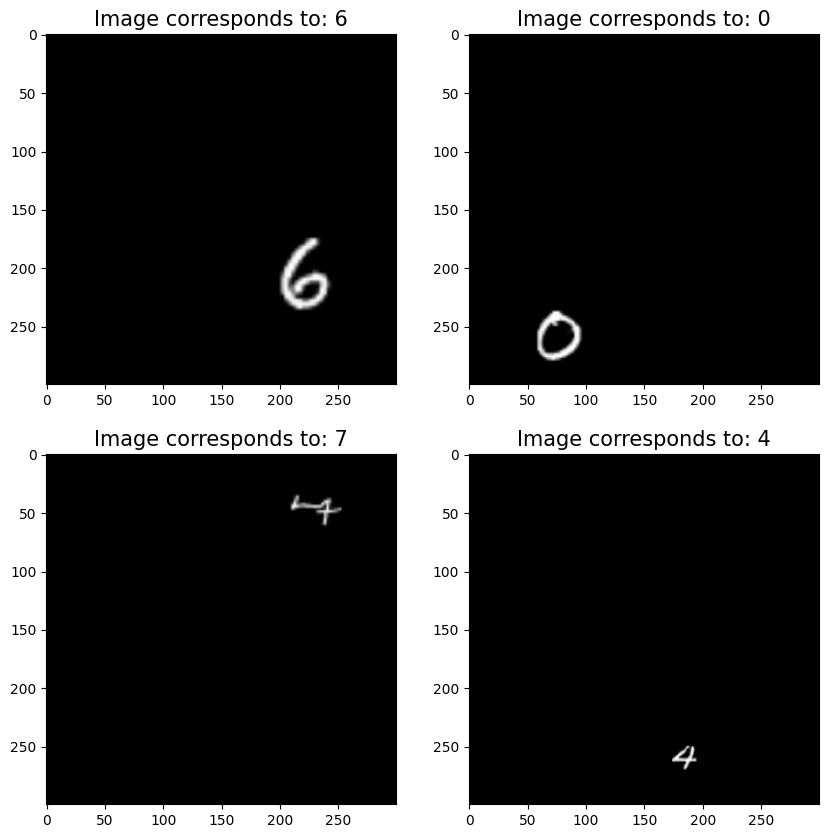

In [54]:
# f = plt.figure(figsize=(100,100))
f, axarr = plt.subplots(2,2,figsize=(10,10))
axarr[0,0].imshow(X_train[100])
axarr[0,0].set_title("Image corresponds to: " + str(y_train[100]),{'fontsize':15})
axarr[0,1].imshow(X_train[200])
axarr[0,1].set_title("Image corresponds to: " + str(y_train[200]),{'fontsize':15})
axarr[1,0].imshow(X_train[300])
axarr[1,0].set_title("Image corresponds to: " + str(y_train[300]),{'fontsize':15})
axarr[1,1].imshow(X_train[400])
axarr[1,1].set_title("Image corresponds to: " + str(y_train[400]),{'fontsize':15})

In [78]:
## Visualizing the Bounding Boxes
def plot_boxes(index):
  (startX, endX,startY, endY) = y_train_boxes_scaled[index]                     # Getting the coordinates of the boxes
  images = X_train[index]                                                       # Getting the image
  (h, w,_) = X_train[0].shape                                                   # Getting the height and width

  # Getting the coordinates to original height and width
  startX = int(startX*w)
  startY = int(startY*h)
  endX = int(endX*w)
  endY = int(endY*h)

  label = y_train[index]                                                        # Getting the label
  imgHeight, imgWidth, _ = images.shape                                         # Getting the height and width of the image
  thick = int((imgHeight + imgWidth) // 900)                                    # Giving a random thickness value for the rectangle
  color = (0,255,0)                                                             # Giving a color to the rectangle box

  # plotting the rectangle on the image with title
  cv2.rectangle(images,(startX, startY), (endX, endY), (0,255,0), thick)            # Plotting the rectangle box on the image
  cv2.putText(images, str(label), (startX, startY - 12), 0, 1* imgHeight, color)
  plt.title("Image corresponds to: " + str(label),{'fontsize':15})
  plt.imshow(images)



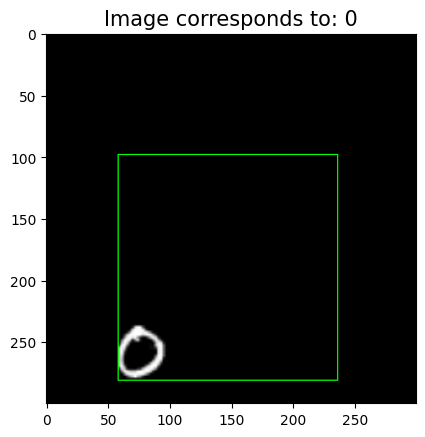

In [79]:
plot_boxes(200)

In [63]:
X_train[0].shape

(300, 300, 3)

In [66]:
(startX, endX,startY, endY) = y_train_boxes_scaled[0]
print(startX)
print(endX)
print(startY)
print(endY)


0.9
0.87
0.9433333333333334
0.9333333333333333


In [67]:
 label = y_train[0]
 label

np.int64(6)

In [68]:
images = X_train[0]
images.shape

(300, 300, 3)